In [121]:
import h5py
import numpy as np
from astropy import units
from IPython.display import clear_output
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.colors import LinearSegmentedColormap

In [122]:
data = h5py.File("TNG100-1_subhalosCat.hdf5", 'r')

access data:

In [123]:
#get data functions with correct units
def gethubble(data):
    hubble_param = data["Header"].attrs["HubbleParam"]
    return hubble_param

def getbox_size(data):
    hubble_param = gethubble(data)
    raw_box_size = data["Header"].attrs["BoxSize"]
    box_size = (raw_box_size / hubble_param) * units.kpc
    return box_size

#position of subhalo compared to periodic box. Position is of particle with minimum gravitational potential energy.
def getsubhalo_pos(data):
    hubble_param = gethubble(data)
    raw_subhalo_pos = data["Subhalo"]["SubhaloPos"]                  #is in ckpc/h
    subhalo_pos = (raw_subhalo_pos / hubble_param) * units.kpc
    return subhalo_pos

#cm of each subhalo, determined with all types of particles.
def getsubhalo_cm(data):
    hubble_param = gethubble(data)
    raw_subhalo_cm = data["Subhalo"]["SubhaloCM"]                    #is in ckpc/h
    subhalo_cm = (raw_subhalo_cm / hubble_param) * units.kpc
    return subhalo_cm

#total mass of all particles of subhalo. subhalo's of a subhalo not included in mass.
def getsubhalo_mass(data):
    hubble_param = gethubble(data)
    raw_subhalo_mass = data["Subhalo"]["SubhaloMass"]                #is in 10**10 solmass/h
    subhalo_mass = (raw_subhalo_mass*1e10/hubble_param) * units.Msun
    return subhalo_mass

#total mass of subhalo by particle type. 
def getsubhalo_massbytype(data):
    hubble_param = gethubble(data)
    raw_subhalo_massbytype = np.array(data["Subhalo"]["SubhaloMassType"])      #is in 10**10 solmass/h
    subhalo_massbytype = (raw_subhalo_massbytype*1e10/hubble_param) * units.Msun
    #Nx6, [Gas, DM, UNUSED, Tracers, Stars/wind particles, Black holes]
    return subhalo_massbytype

#radius where surface brightness profile drops below limit.
def getsubhalo_stellar_photometrics_radius(data):
    hubble_param = gethubble(data)
    raw_subhalo_stellar_photometrics_radius = np.array(data["Subhalo"]["SubhaloStellarPhotometricsRad"])
    subhalo_stellar_photometrics_radius = (raw_subhalo_stellar_photometrics_radius / hubble_param) * units.kpc
    return subhalo_stellar_photometrics_radius

def getsubhalo_stellar_photometrics_massinrad(data):
    hubble_param = gethubble(data)
    raw_subhalo_stellar_photometrics_massinrad = np.array(data["Subhalo"]["SubhaloStellarPhotometricsMassInRad"])
    subhalo_stellar_photometrics_massinrad = (raw_subhalo_stellar_photometrics_massinrad*1e10/hubble_param) * units.Msun
    return subhalo_stellar_photometrics_massinrad

differentiate galaxies from subhalos:

In [124]:
#boolean numpy array stating if a subhalo at that index contains a galaxy. 
def getgalaxy_mask(data):
    total_mass = getsubhalo_massbytype(data)
    stellar_mass = total_mass[:,4]

    mask = (stellar_mass > 0.0)
    return mask

def getgalaxy_cm(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_cm = getsubhalo_cm(data)
    galaxy_cm = subhalo_cm[galaxy_mask, :]
    return galaxy_cm

def getgalaxy_stellar_photometrics_radius(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_stellar_photometrics_radius = getsubhalo_stellar_photometrics_radius(data)
    galaxy_stellar_photometrics_radius = subhalo_stellar_photometrics_radius[galaxy_mask]
    return galaxy_stellar_photometrics_radius

def getgalaxy_stellar_photometrics_massinrad(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_stellar_photometrics_massinrad = getsubhalo_stellar_photometrics_massinrad(data)
    galaxy_stellar_photometrics_massinrad = subhalo_stellar_photometrics_massinrad[galaxy_mask]
    return galaxy_stellar_photometrics_massinrad

1) Mass-Radius relation

Plot demonstrating TNG100 artifact, the minimal stellar resolution is 740pc for TNG100 (log(740) = 2.87) https://www.tng-project.org/about/, while also being calculated discretely, meaning most low stellar radius galaxies get rounded down to this minimum. The same goes for the baryon mass resolution m=1.4*$10^{6}$ solar masses.

In [125]:
def plot_mass_radius_TNG100_artifact(): 
    stelpho_radius = getgalaxy_stellar_photometrics_radius(data).to("pc")
    stelpho_massinrad = getgalaxy_stellar_photometrics_massinrad(data)

    #no masses or radiai lower than 0 allowed
    mask_rad = stelpho_radius>0*stelpho_radius.unit 
    mask_mass = stelpho_massinrad>0*stelpho_massinrad.unit
    mask = np.logical_and(mask_rad, mask_mass)
    stelpho_radius = stelpho_radius[mask]
    stelpho_massinrad = stelpho_massinrad[mask]

    stelpho_radius_log = np.log10(stelpho_radius.value)
    stelpho_massinrad_log = np.log10(stelpho_massinrad.value)

    fig = plt.figure(figsize=(10,10), dpi=200)
    
    plt.subplot(1, 2, 1)
    plt.scatter(stelpho_massinrad_log, stelpho_radius_log, s=1, c="blue", label="TNG100 Data", alpha=0.3)
    plt.axhline(y=np.log10(740), color='green', linestyle='--', label="Spatial resolution", alpha=0.6)
    plt.axvline(x=np.log10(1.4e6), color="black", linestyle='--', label="Stellar mass resolution", alpha=0.6)
    plt.legend()
    plt.xlabel(f"log(M) ({stelpho_massinrad.unit})")
    plt.ylabel(f"log(R) ({stelpho_radius.unit})")
    plt.title("Mass-radius scatterplot")

    plt.subplot(1, 2, 2)
    plt.axhline(y=np.log10(740), color='green', linestyle='--', label="Spatial resolution", alpha=0.6)
    plt.axvline(x=np.log10(1.4e6), color="black", linestyle='--', label="Stellar mass resolution", alpha=0.6)
    plt.xlabel(f"log(M) ({stelpho_massinrad.unit})")
    plt.ylabel(f"log(R) ({stelpho_radius.unit})")
    
    plt.legend()

    plt.hist2d(stelpho_massinrad_log, stelpho_radius_log, bins=(100,100), cmap="RdBu")
    plt.colorbar(label="Galaxies per pixel")
    plt.title("Mass-radius heatmap")
    plt.savefig("mass_radius_tng100_artifact")
    plt.show()

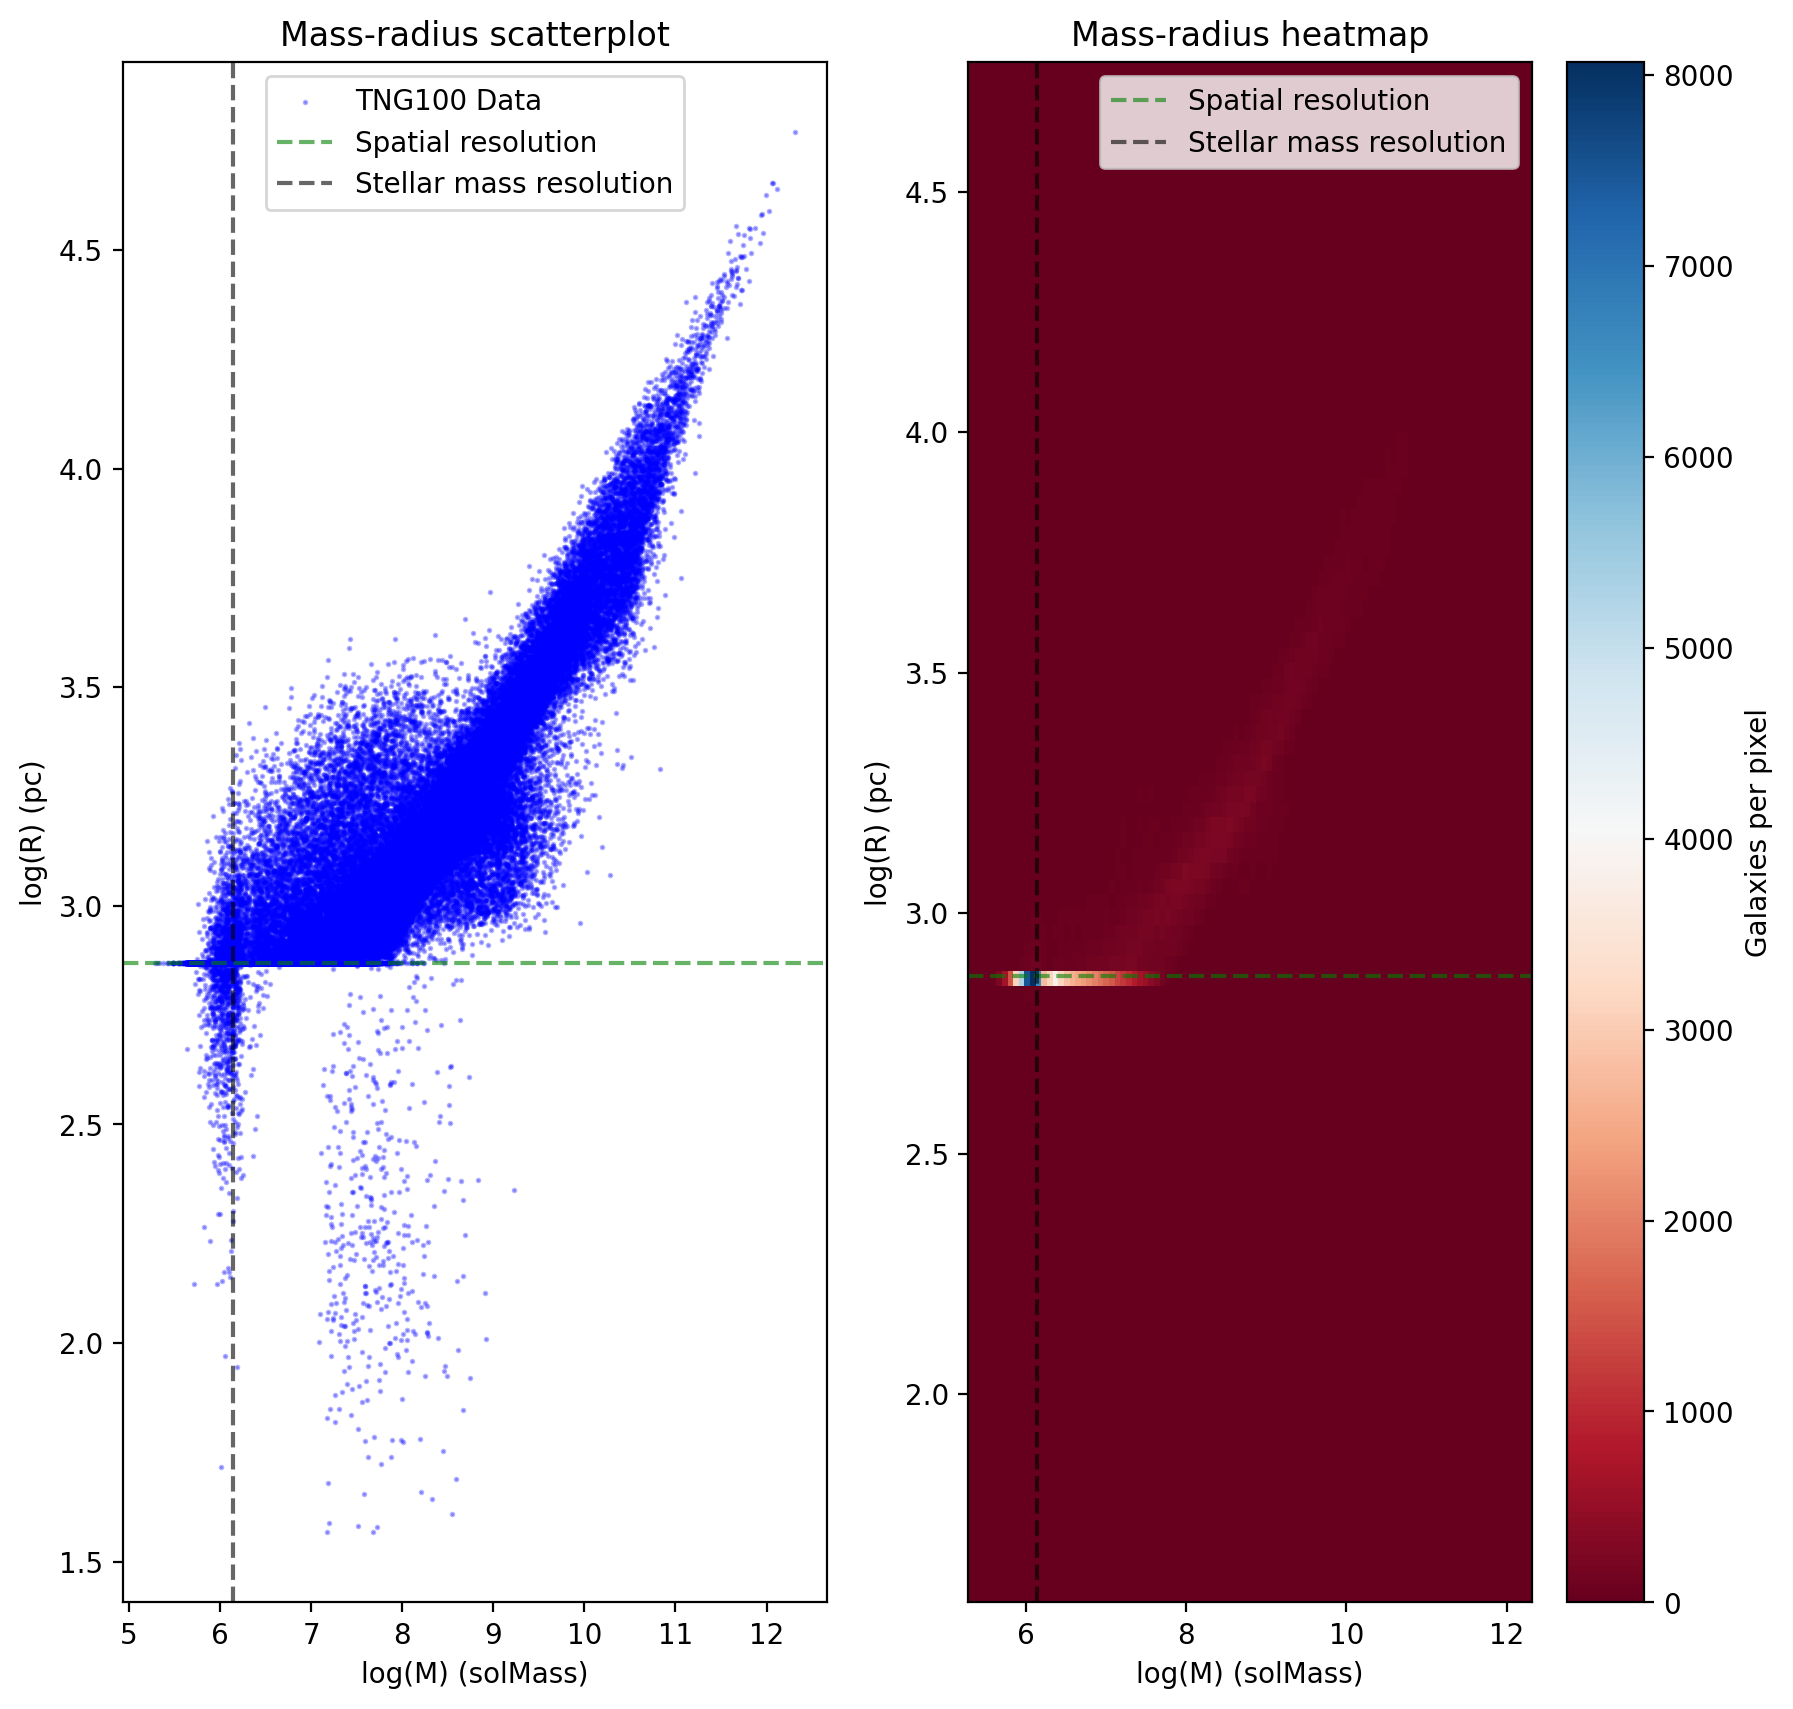

In [126]:
plot_mass_radius_TNG100_artifact()

Plot showing theoretical relations for high mass and low mass galaxies

In [127]:
#relations found in 
def high_mass_radius(mass, amp=0.8):
    radius = amp*(mass**0.39)*units.pc
    return radius

def low_mass_radius(mass, amp=120.0):
    radius = amp*(mass**0.14)*units.pc
    return radius

In [128]:
# "Viridis-like" colormap with white background
white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.2, '#404388'),
    (0.4, '#2a788e'),
    (0.6, '#21a784'),
    (0.8, '#78d151'),
    (1, '#fde624'),
], N=256)

In [129]:
def plot_mass_radius_relation():
    stelpho_radius = getgalaxy_stellar_photometrics_radius(data).to("pc")
    stelpho_massinrad = getgalaxy_stellar_photometrics_massinrad(data)

    #Only look at galaxies with masses and radiai larger than resolution
    resolution_radius = 740*units.pc
    resolution_mass = 1.4e6*units.M_sun
    
    mask_rad = stelpho_radius > resolution_radius
    mask_mass = stelpho_massinrad > resolution_mass
    mask = np.logical_and(mask_rad, mask_mass)
    stelpho_radius = stelpho_radius[mask]
    stelpho_massinrad = stelpho_massinrad[mask]

    stelpho_radius_log = np.log10(stelpho_radius.value)
    stelpho_massinrad_log = np.log10(stelpho_massinrad.value)

    high_mass_log = np.log10(high_mass_radius(stelpho_massinrad, amp=0.65).value)*stelpho_radius.unit
    low_mass_log = np.log10(low_mass_radius(stelpho_massinrad, amp=92).value)*stelpho_radius.unit

    fig = plt.figure(figsize=(10,10), dpi=200)
    
    #plt.scatter(stelpho_massinrad_log, stelpho_radius_log, s=1, c="blue", label="Data", alpha=0.3)
    plt.hist2d(stelpho_massinrad_log, stelpho_radius_log, bins=(250,250), cmap=white_viridis)
    plt.colorbar(label="Galaxies per pixel")
    plt.plot(stelpho_massinrad_log, high_mass_log, c="red", label="High-mass galaxy hand-fit: R∝$M^{0.39}$")
    plt.plot(stelpho_massinrad_log, low_mass_log, c="blue", label="Low-mass galaxy hand-fit: R∝$M^{0.14}$")
    
    plt.title(f"Mass-radius relation for high-mass galaxies")
    plt.xlabel(f"log(M) ({stelpho_massinrad.unit})")
    plt.ylabel(f"log(R) ({stelpho_radius.unit})")
    plt.xscale("linear")
    plt.yscale("linear")
    
    plt.legend()
    plt.savefig("mass_radius_fits")
    plt.show()

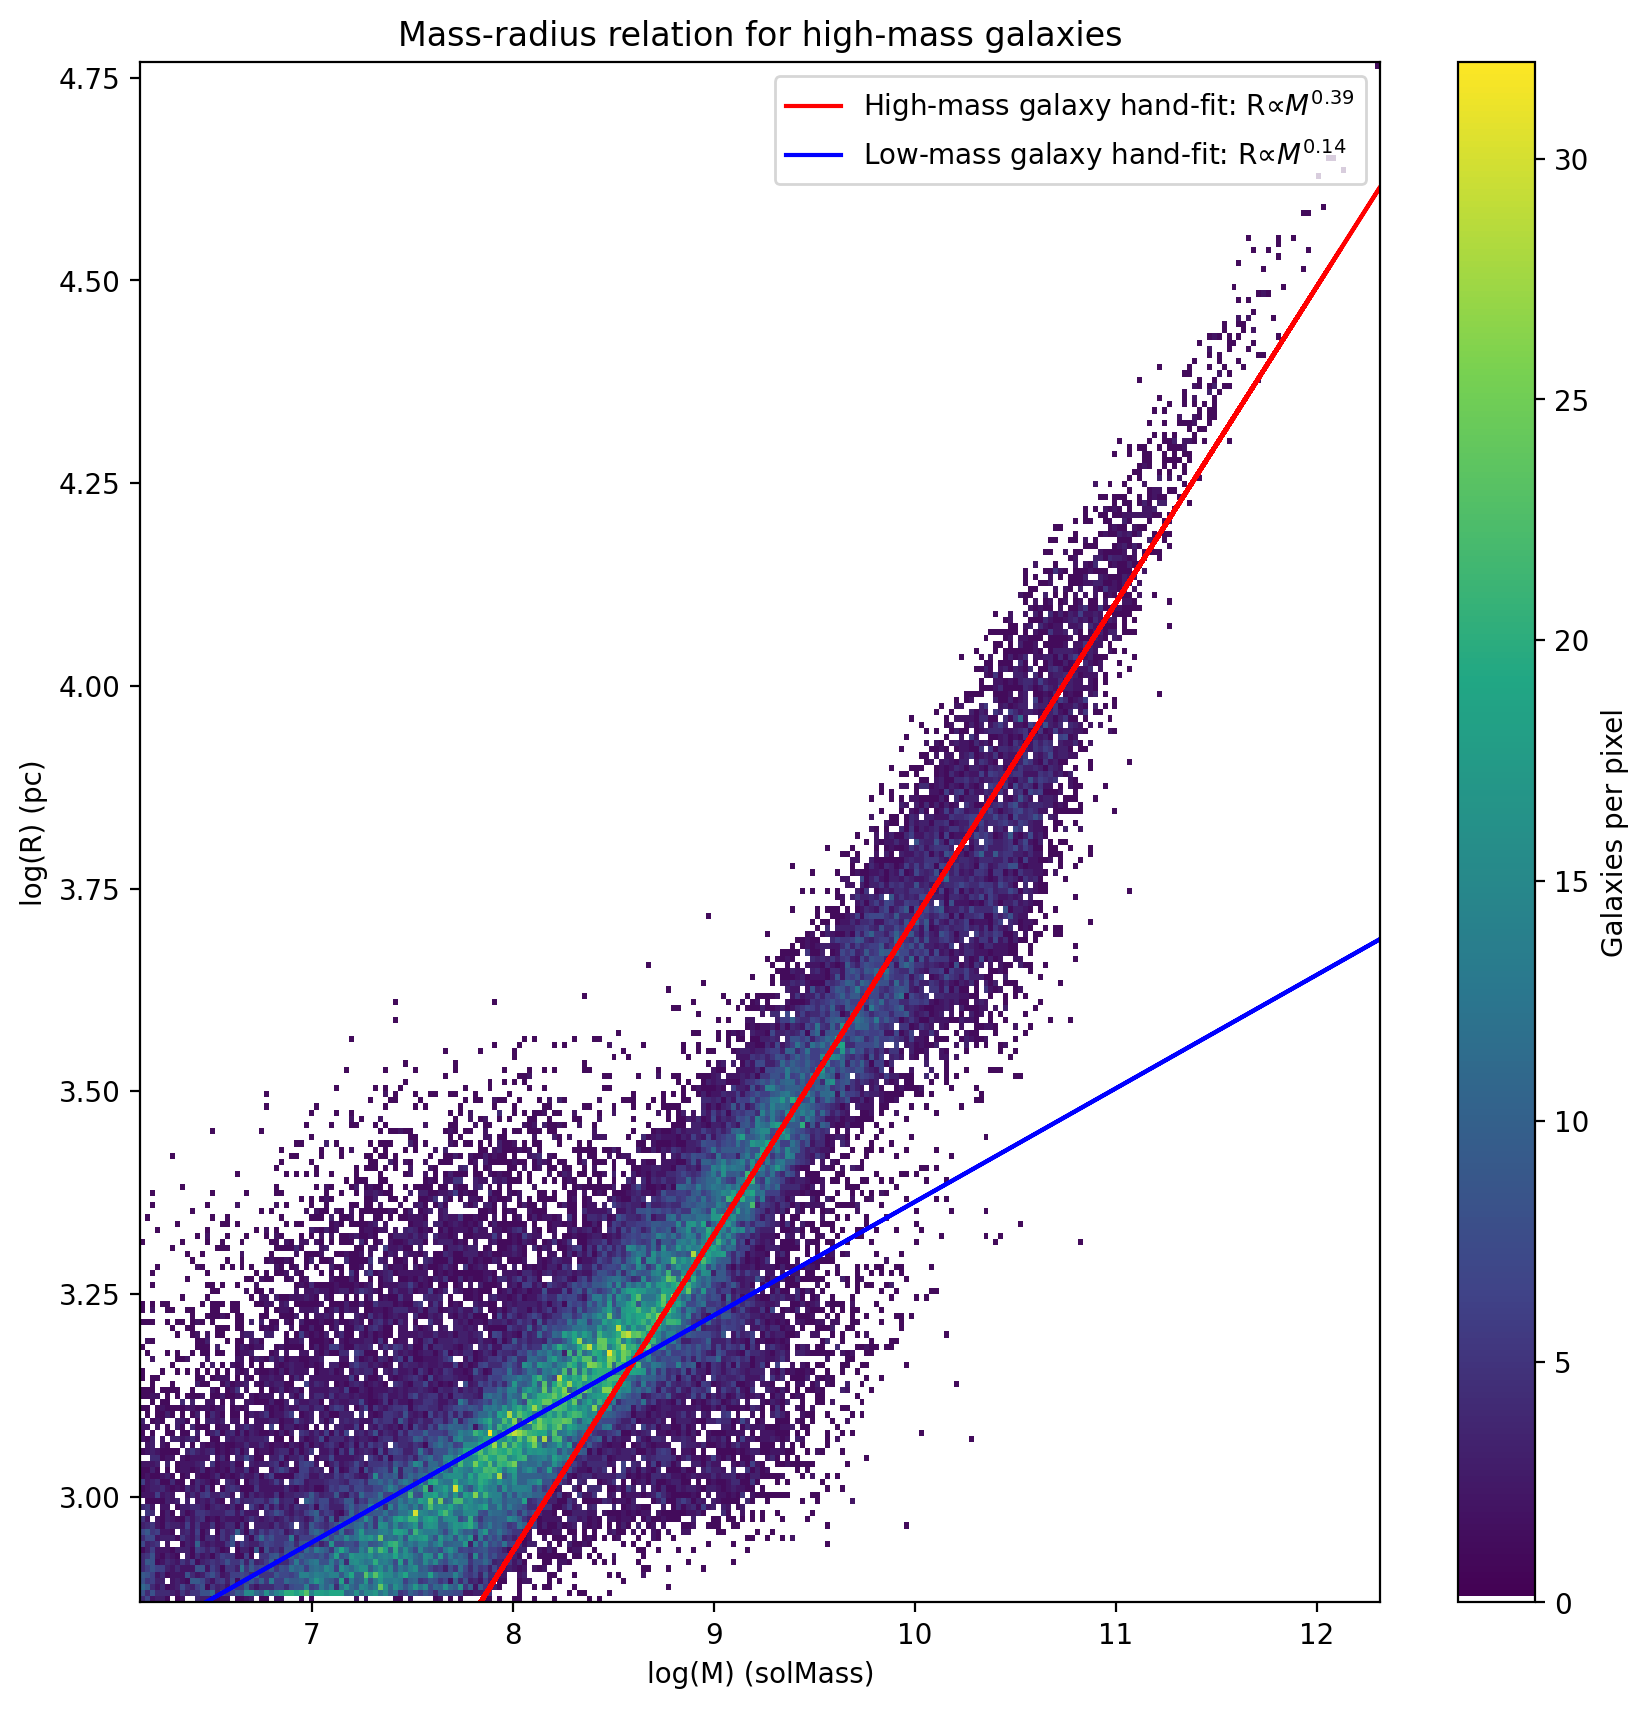

In [130]:
plot_mass_radius_relation()

Relation 2: FABER-JACKSON RELATION (correlation between the total luminosity of early-type galaxies (ETGs) L and the central
velocity dispersion of their stars σ), see chapter 2 from the link above

In [131]:
def getsubhalo_veldisp(data):
    raw_onedim_veldisp = data["Subhalo"]["SubhaloVelDisp"]
    onedim_veldisp = raw_onedim_veldisp * units.km / units.s
    return onedim_veldisp

def getgalaxy_veldisp(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_onedim_veldisp = getsubhalo_veldisp(data)
    galaxy_onedim_veldisp = subhalo_onedim_veldisp[galaxy_mask]
    return galaxy_onedim_veldisp

#focus on the U-band
def getgalaxy_stellarphotometrics(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_magnitude = data["Subhalo"]["SubhaloStellarPhotometrics"][:,0] 
    galaxy_magnitude = subhalo_magnitude[galaxy_mask]
    return galaxy_magnitude
    

In [132]:
def plot_magnitude_veldisp():
    veldisp = getgalaxy_veldisp(data)
    magnitude = getgalaxy_stellarphotometrics(data)

    fig = plt.figure(figsize=(10,10), dpi=200)
    plt.suptitle("Faber-Jackson relation")
    
    plt.subplot(1, 2, 1)
    plt.scatter(magnitude, np.log10(veldisp.value), s=1)
    plt.xlabel(f"Absolute magnitude")
    plt.ylabel(f"log(σ)({veldisp.unit})")
    plt.title("Scatterplot")

    plt.subplot(1, 2, 2)
    plt.hist2d(magnitude, np.log10(veldisp.value), bins=(200,400), cmap=white_viridis)
    plt.colorbar(label="Galaxies per pixel")
    plt.title("Heatmap")

    #L order sigma**4
    #plt.title("Faber-Jackson relation")
    plt.xlabel(f"Absolute magnitude")
    plt.ylabel(f"log(σ)({veldisp.unit})")

    plt.savefig("faber_jackson_scatter_heat")
    plt.show()

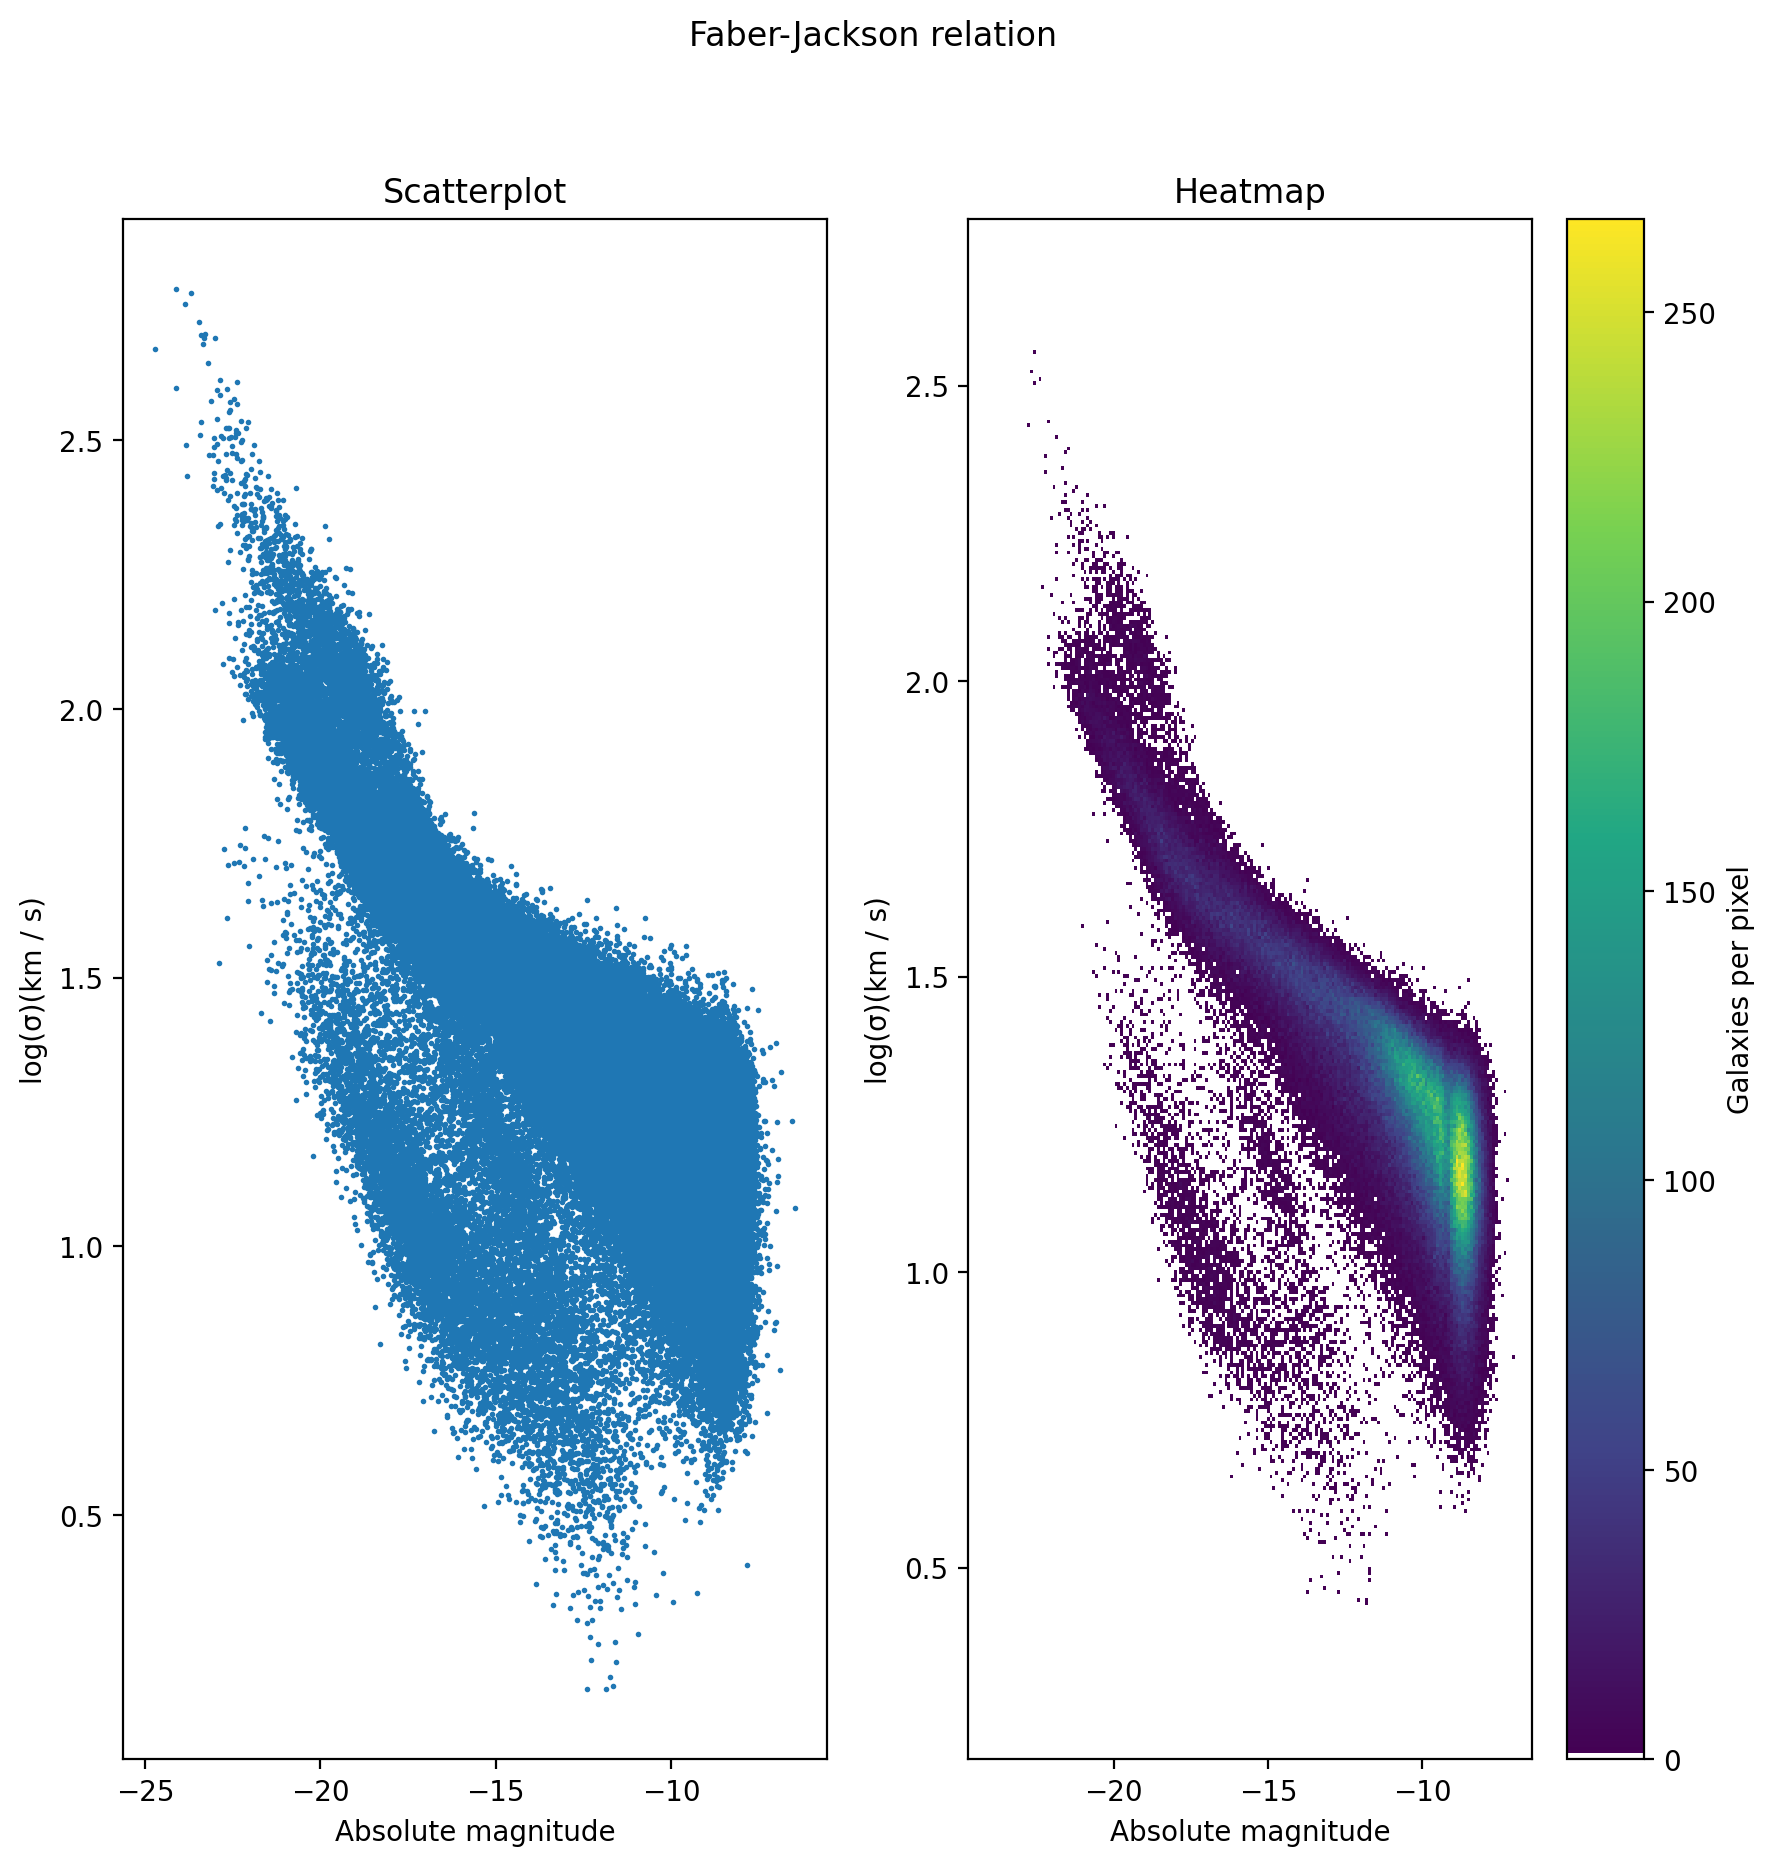

In [133]:
plot_magnitude_veldisp()

In [134]:
def faber_jackson(sigma, amplitude, power):
    luminoscity = amplitude*(sigma**power)
    magn = -2.5*np.log10(luminoscity)
    return magn

def faber_jackson_log(sigma_log, amplitude, power):
    sigma = 10**sigma_log
    luminoscity = amplitude*(sigma**power)
    magn = -2.5*np.log10(luminoscity)
    return magn

def plot_magnitude_veldisp_relation():
    veldisp = getgalaxy_veldisp(data)
    magnitude = getgalaxy_stellarphotometrics(data)

    fig = plt.figure(figsize=(10,10), dpi=200)
    plt.title("Faber-Jackson relation")

    #plt.yscale("log")
    #plt.scatter(magnitude, np.log10(veldisp.value))
    plt.hist2d(magnitude, np.log10(veldisp.value), bins=(400,400), cmap=white_viridis)
    plt.colorbar(label="Galaxies per pixel")

    power = 4.0
    veldisp_fit = np.linspace(1, 10, 100) * veldisp.unit
    magn_fit = faber_jackson_log(veldisp_fit.value, amplitude=0.07, power=power)

    #plt.yscale("log")
    plt.plot(magn_fit, veldisp_fit, c="red", label="Faber-Jackson hand-fit: L∝$σ^{" + str(power) + "}$")
    plt.legend()

    plt.xlabel(f"Absolute magnitude")
    plt.ylabel(f"log(σ)({veldisp.unit})")

    plt.savefig("faber_jackson_fit")
    plt.show()

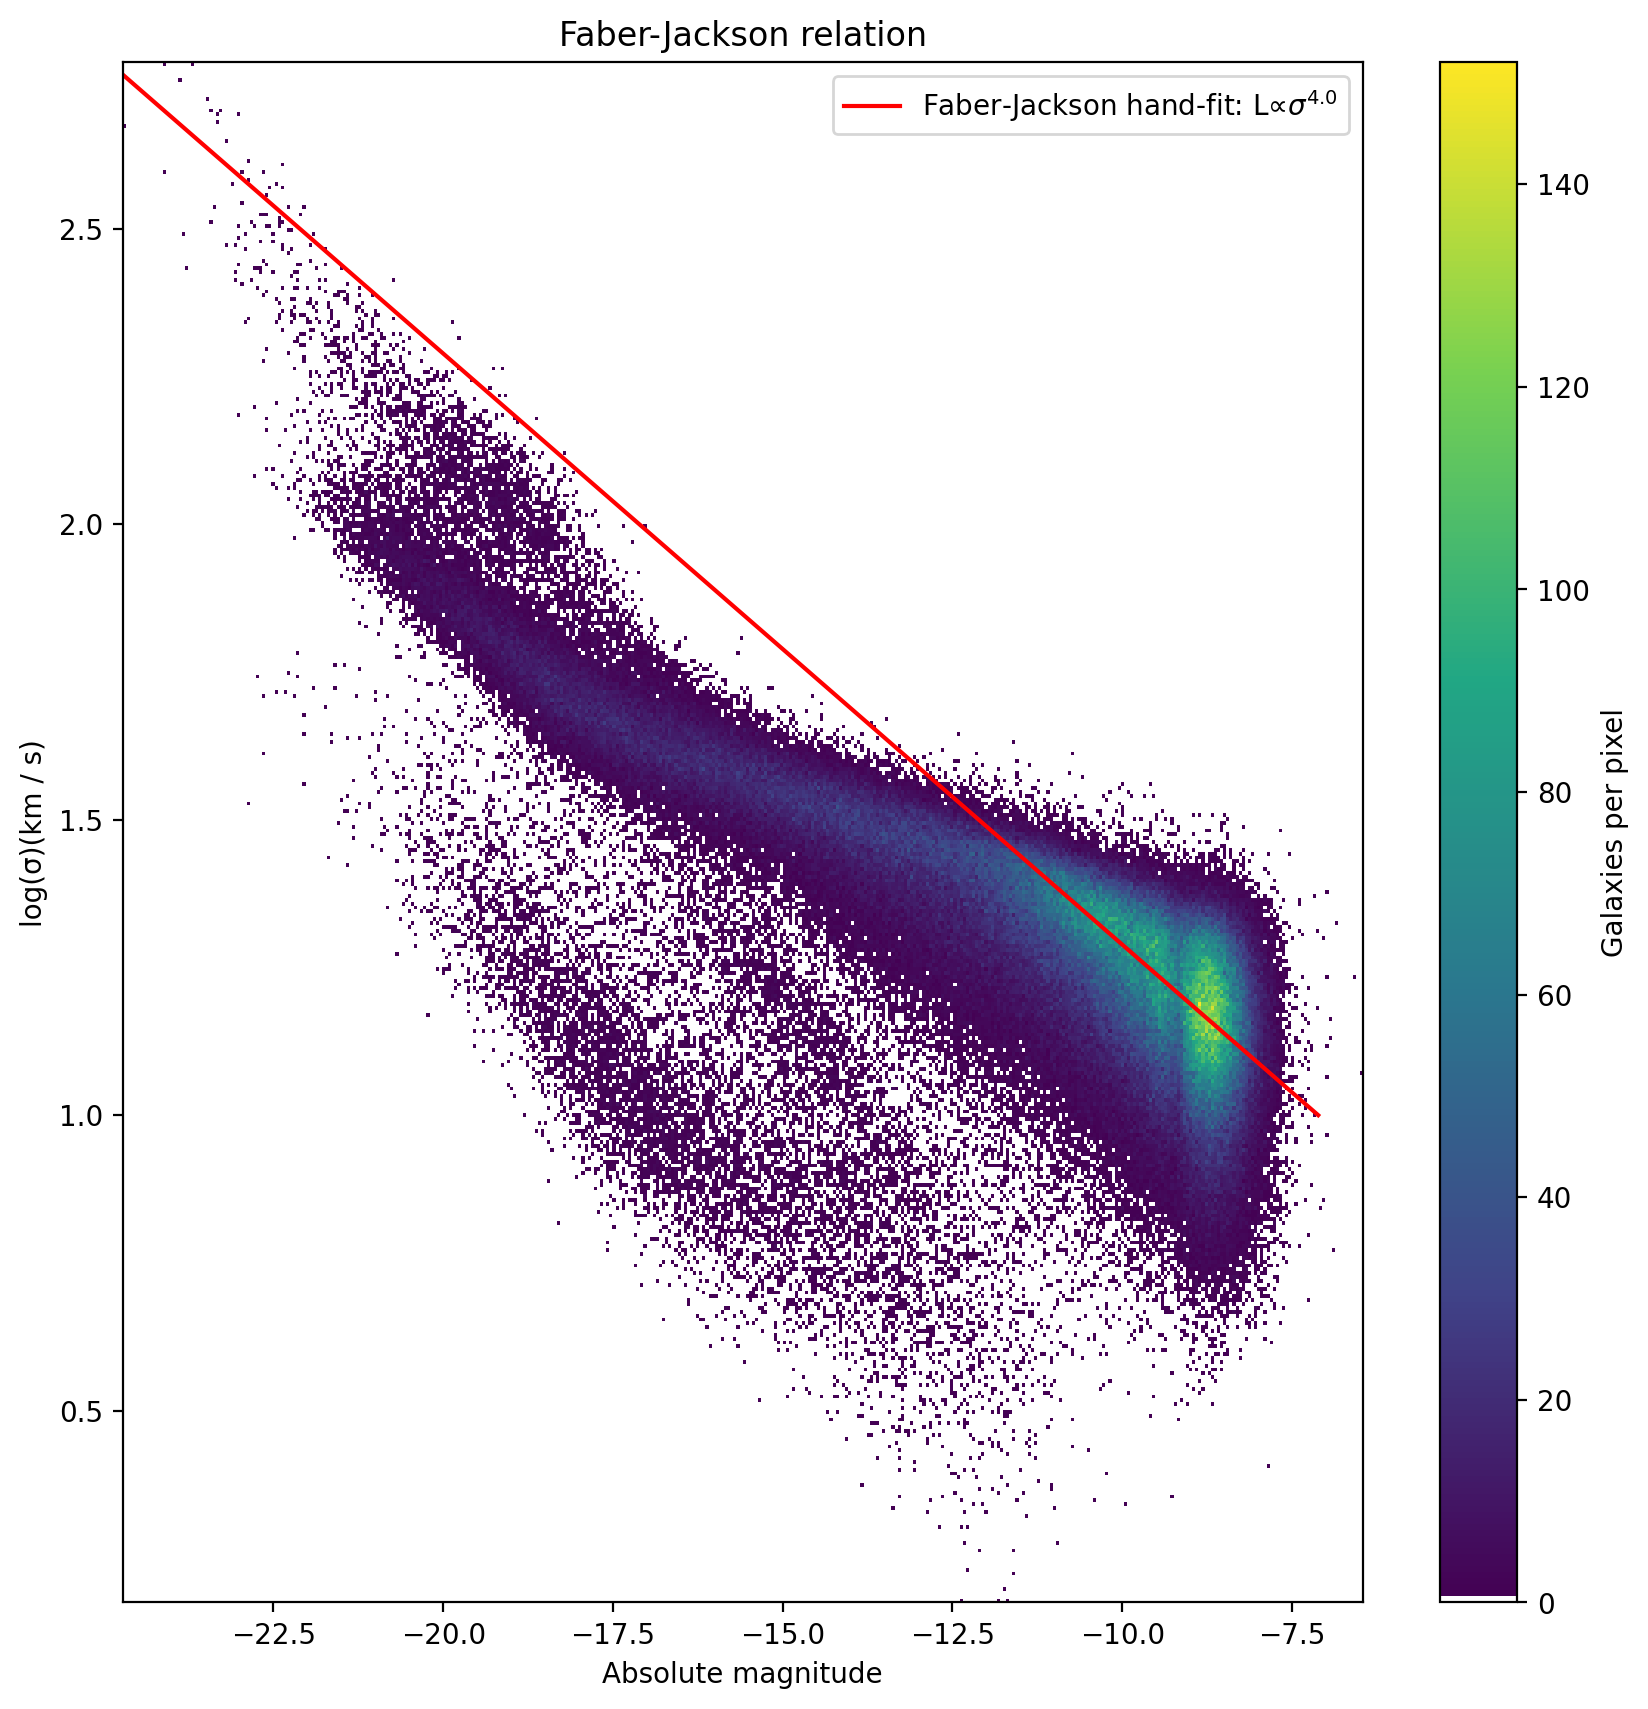

In [135]:
plot_magnitude_veldisp_relation()